# Definition & Guideline Embedding Analysis\n\nVisualize semantic similarity of argument definitions and guidelines across 10 datasets using OpenAI embeddings + UMAP.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from openai import OpenAI
import umap

# Thesis-quality styling
plt.rcParams.update({"figure.dpi": 150, "axes.titlesize": 14, "axes.labelsize": 12})
sns.set_theme(style="whitegrid", palette="colorblind")

/Users/hanneswidera/Uni/Master/thesis/GAIC_thesis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load all definitions
DATASETS = ["ABSTRCT", "ACQUA", "AEC", "AFS", "ARGUMINSCI", "FINARG", "IAM", "PE", "SCIARK", "USELEC"]
CONTEXT_DIR = Path("../../context")

definitions = {}
for ds in DATASETS:
    definitions[ds] = (CONTEXT_DIR / ds / "definition.md").read_text().strip()
    print(f"{ds}: {len(definitions[ds])} chars")

ABSTRCT: 1035 chars
ACQUA: 682 chars
AEC: 816 chars
AFS: 965 chars
ARGUMINSCI: 922 chars
FINARG: 858 chars
IAM: 620 chars
PE: 1005 chars
SCIARK: 642 chars
USELEC: 732 chars


In [3]:
# Embed definitions with OpenAI
client = OpenAI()

response = client.embeddings.create(
    model="text-embedding-3-small",
    input=list(definitions.values()),
)

embeddings = np.array([e.embedding for e in response.data])
print(f"Embeddings shape: {embeddings.shape}")

Embeddings shape: (10, 1536)


In [4]:
# UMAP projection to 2D
reducer = umap.UMAP(
    n_neighbors=5,
    min_dist=0.1,
    n_components=2,
    metric="cosine",
    random_state=42
)
coords = reducer.fit_transform(embeddings)
print(f"UMAP coords shape: {coords.shape}")

/Users/hanneswidera/Uni/Master/thesis/GAIC_thesis/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP coords shape: (10, 2)


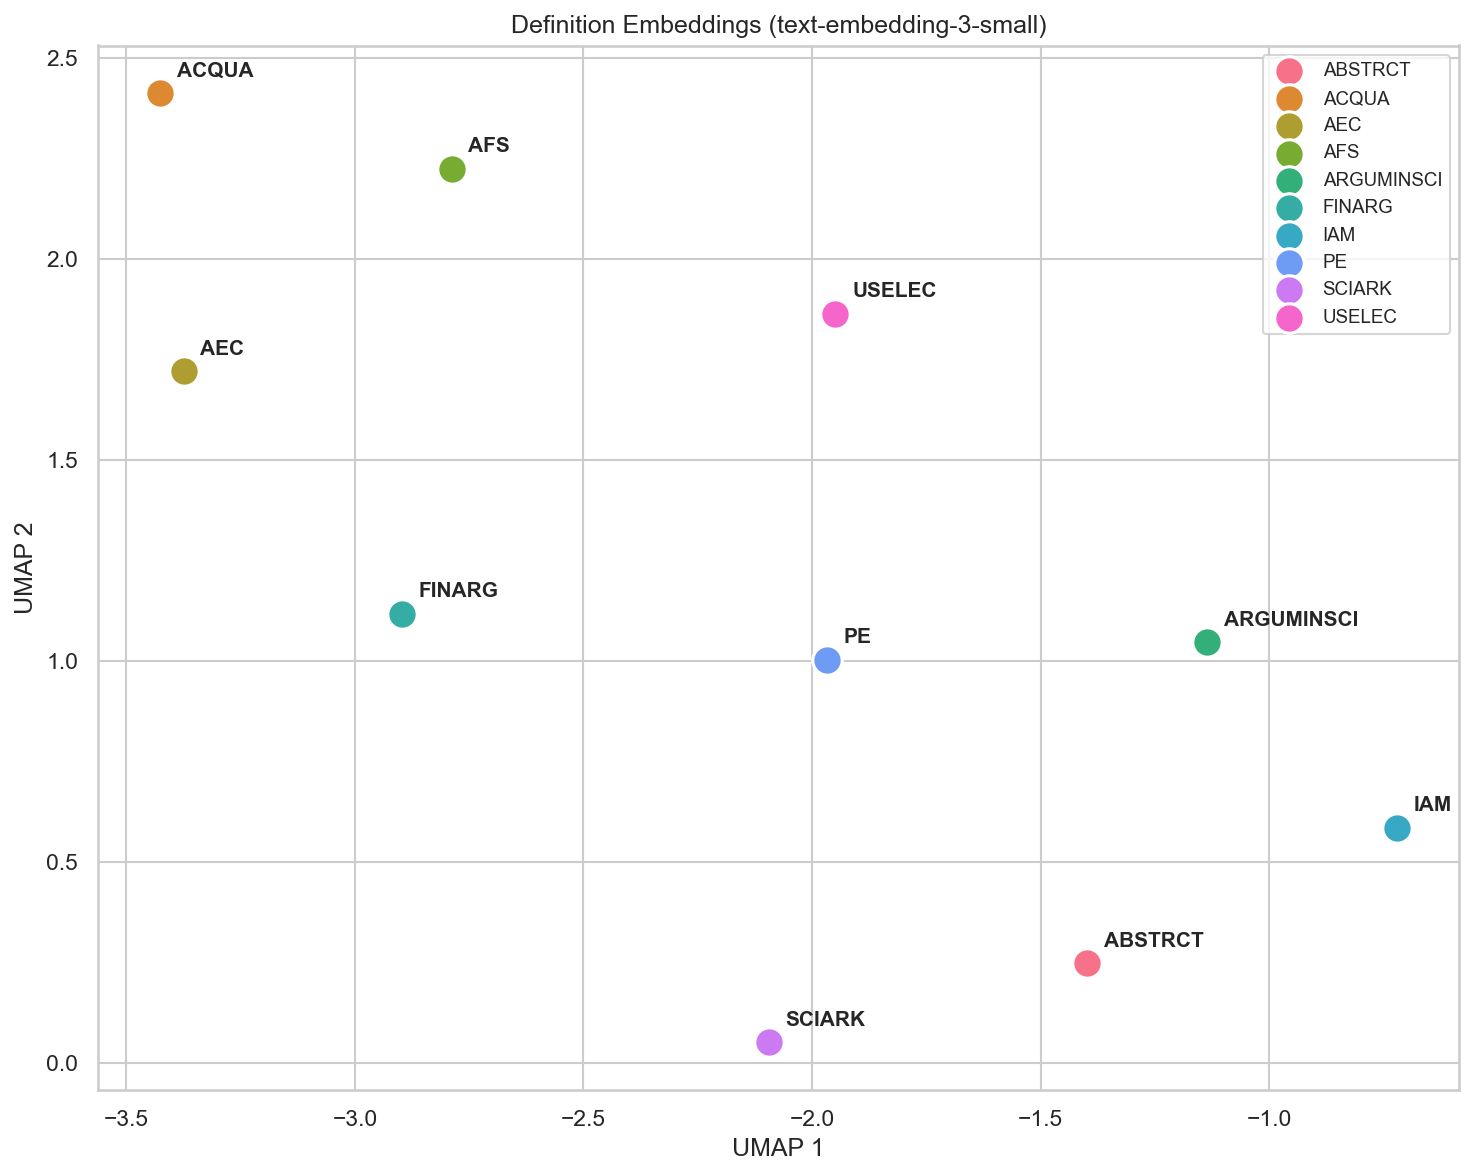

In [5]:
# Visualization
fig, ax = plt.subplots(figsize=(10, 8))

colors = sns.color_palette("husl", len(DATASETS))

for i, ds in enumerate(DATASETS):
    ax.scatter(coords[i, 0], coords[i, 1], c=[colors[i]], s=200, label=ds, edgecolors="white", linewidth=1.5)
    ax.annotate(ds, (coords[i, 0], coords[i, 1]), fontsize=10, fontweight="bold",
                xytext=(8, 8), textcoords="offset points")

ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("Definition Embeddings (text-embedding-3-small)")
ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig("definition_embeddings.png", dpi=300, bbox_inches="tight")
plt.savefig("definition_embeddings.pdf", bbox_inches="tight")
plt.show()

In [6]:
# Dataset categories for coloring
CATEGORIES = {
    "ABSTRCT": "Scientific",
    "SCIARK": "Scientific", 
    "ARGUMINSCI": "Scientific",
    "PE": "Educational",
    "USELEC": "Political",
    "IAM": "Debate",
    "AEC": "Debate",
    "AFS": "Debate",
    "ACQUA": "Web",
    "FINARG": "Financial"
}

CATEGORY_COLORS = {
    "Scientific": "#1f77b4",   # blue
    "Educational": "#2ca02c",  # green
    "Political": "#d62728",    # red
    "Debate": "#ff7f0e",       # orange
    "Web": "#9467bd",          # purple
    "Financial": "#8c564b"     # brown
}

In [7]:
# Pydantic schema for structured definition variants
from pydantic import BaseModel, Field

class DefinitionVariants(BaseModel):
    """Three alternative formulations of an argument definition for GoLLIE training."""
    
    checklist: str = Field(
        description="A strict operational step-by-step bulleted checklist with clear yes/no criteria. "
                    "Each bullet should be a verifiable condition for classifying text as Argument."
    )
    minimalist: str = Field(
        description="The most minimal, terse version possible. Maximum 2 sentences. "
                    "Strip all academic filler words while preserving the core classification rule."
    )
    imperative: str = Field(
        description="Aggressive command-driven language starting with 'You must classify this text by strictly verifying...' "
                    "Use direct imperatives and explicit verification steps."
    )

# Generate variants using structured output
alt_definitions = {ds: {"original": definitions[ds]} for ds in DATASETS}

for ds in DATASETS:
    print(f"Generating variants for {ds}...")
    
    response = client.beta.chat.completions.parse(
        model="gpt-4o",
        messages=[
            {"role": "system", "content": "You are an expert at reformulating annotation guidelines into different styles while preserving semantic meaning."},
            {"role": "user", "content": f"Create three alternative formulations of this argument definition:\n\n{definitions[ds]}"}
        ],
        response_format=DefinitionVariants,
        temperature=0.7
    )
    
    variants = response.choices[0].message.parsed
    alt_definitions[ds]["checklist"] = variants.checklist
    alt_definitions[ds]["minimalist"] = variants.minimalist
    alt_definitions[ds]["imperative"] = variants.imperative

print("Done!")

Generating variants for ABSTRCT...
Generating variants for ACQUA...
Generating variants for AEC...
Generating variants for AFS...
Generating variants for ARGUMINSCI...
Generating variants for FINARG...
Generating variants for IAM...
Generating variants for PE...
Generating variants for SCIARK...
Generating variants for USELEC...
Done!


In [ ]:
# Display generated variants
from IPython.display import display, Markdown

for ds in DATASETS:
    display(Markdown(f"## {ds} ({CATEGORIES[ds]})"))
    display(Markdown(f"**Original** ({len(alt_definitions[ds]['original'])} chars):\n> {alt_definitions[ds]['original'][:200]}..."))
    display(Markdown(f"**Checklist** ({len(alt_definitions[ds]['checklist'])} chars):\n> {alt_definitions[ds]['checklist'][:200]}..."))
    display(Markdown(f"**Minimalist** ({len(alt_definitions[ds]['minimalist'])} chars):\n> {alt_definitions[ds]['minimalist']}"))
    display(Markdown(f"**Imperative** ({len(alt_definitions[ds]['imperative'])} chars):\n> {alt_definitions[ds]['imperative'][:200]}..."))
    display(Markdown("---"))

## ABSTRCT (Scientific)

**Original** (1035 chars):
> In this dataset, an argument consists of explicitly annotated argumentative components in Randomized Controlled Trial abstracts, namely claims (including major claims) and evidence. A claim is defined...

**Checklist** (723 chars):
> - Verify that the text contains explicitly annotated argumentative components in the context of Randomized Controlled Trial abstracts.
- Confirm the presence of claims, defined as concluding statement...

**Minimalist** (240 chars):
> An argument includes claims and evidence in RCT abstracts, with claims summarizing study outcomes and evidence supporting or attacking claims. Components relate through support or attack, and absence of these signals non-argumentative text.

**Imperative** (468 chars):
> You must classify this text by strictly verifying the presence of annotated argumentative components: claims and evidence, within RCT abstracts. Ensure claims conclude study outcomes, often regarding ...

...

**Original** (732 chars):
> In the USElecDeb60To16 dataset, an argument is any text span annotated as an argument component, namely a claim or a premise. Claims are the ultimate goals of an argument and include policies advocate...

**Checklist** (433 chars):
> - Does the text span include a claim or premise? If not, it is not an argument.
- Is there a statement that serves as a claim, such as advocating a policy or expressing an opinion that needs justifica...

**Minimalist** (121 chars):
> An argument is any text with a claim or premise. Claims require justification, while premises provide that justification.

**Imperative** (320 chars):
> You must classify this text by strictly verifying the presence of claims or premises. Identify if there are statements advocating policies, making judgments, or expressing opinions that need justifica...

---

In [9]:
# Embed all definition variants
STYLE_NAMES = ["original", "checklist", "minimalist", "imperative"]

all_texts = []
all_meta = []  # (dataset, style)

for ds in DATASETS:
    for style in STYLE_NAMES:
        all_texts.append(alt_definitions[ds][style])
        all_meta.append((ds, style))

response_all = client.embeddings.create(
    model="text-embedding-3-small",
    input=all_texts
)
embeddings_all = np.array([e.embedding for e in response_all.data])
print(f"Total embeddings: {embeddings_all.shape}")

Total embeddings: (40, 1536)


In [10]:
# UMAP projection for all variants
reducer_all = umap.UMAP(
    n_neighbors=8,
    min_dist=0.1,
    n_components=2,
    metric="cosine",
    random_state=42
)
coords_all = reducer_all.fit_transform(embeddings_all)
print(f"UMAP coords: {coords_all.shape}")

UMAP coords: (40, 2)


/Users/hanneswidera/Uni/Master/thesis/GAIC_thesis/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


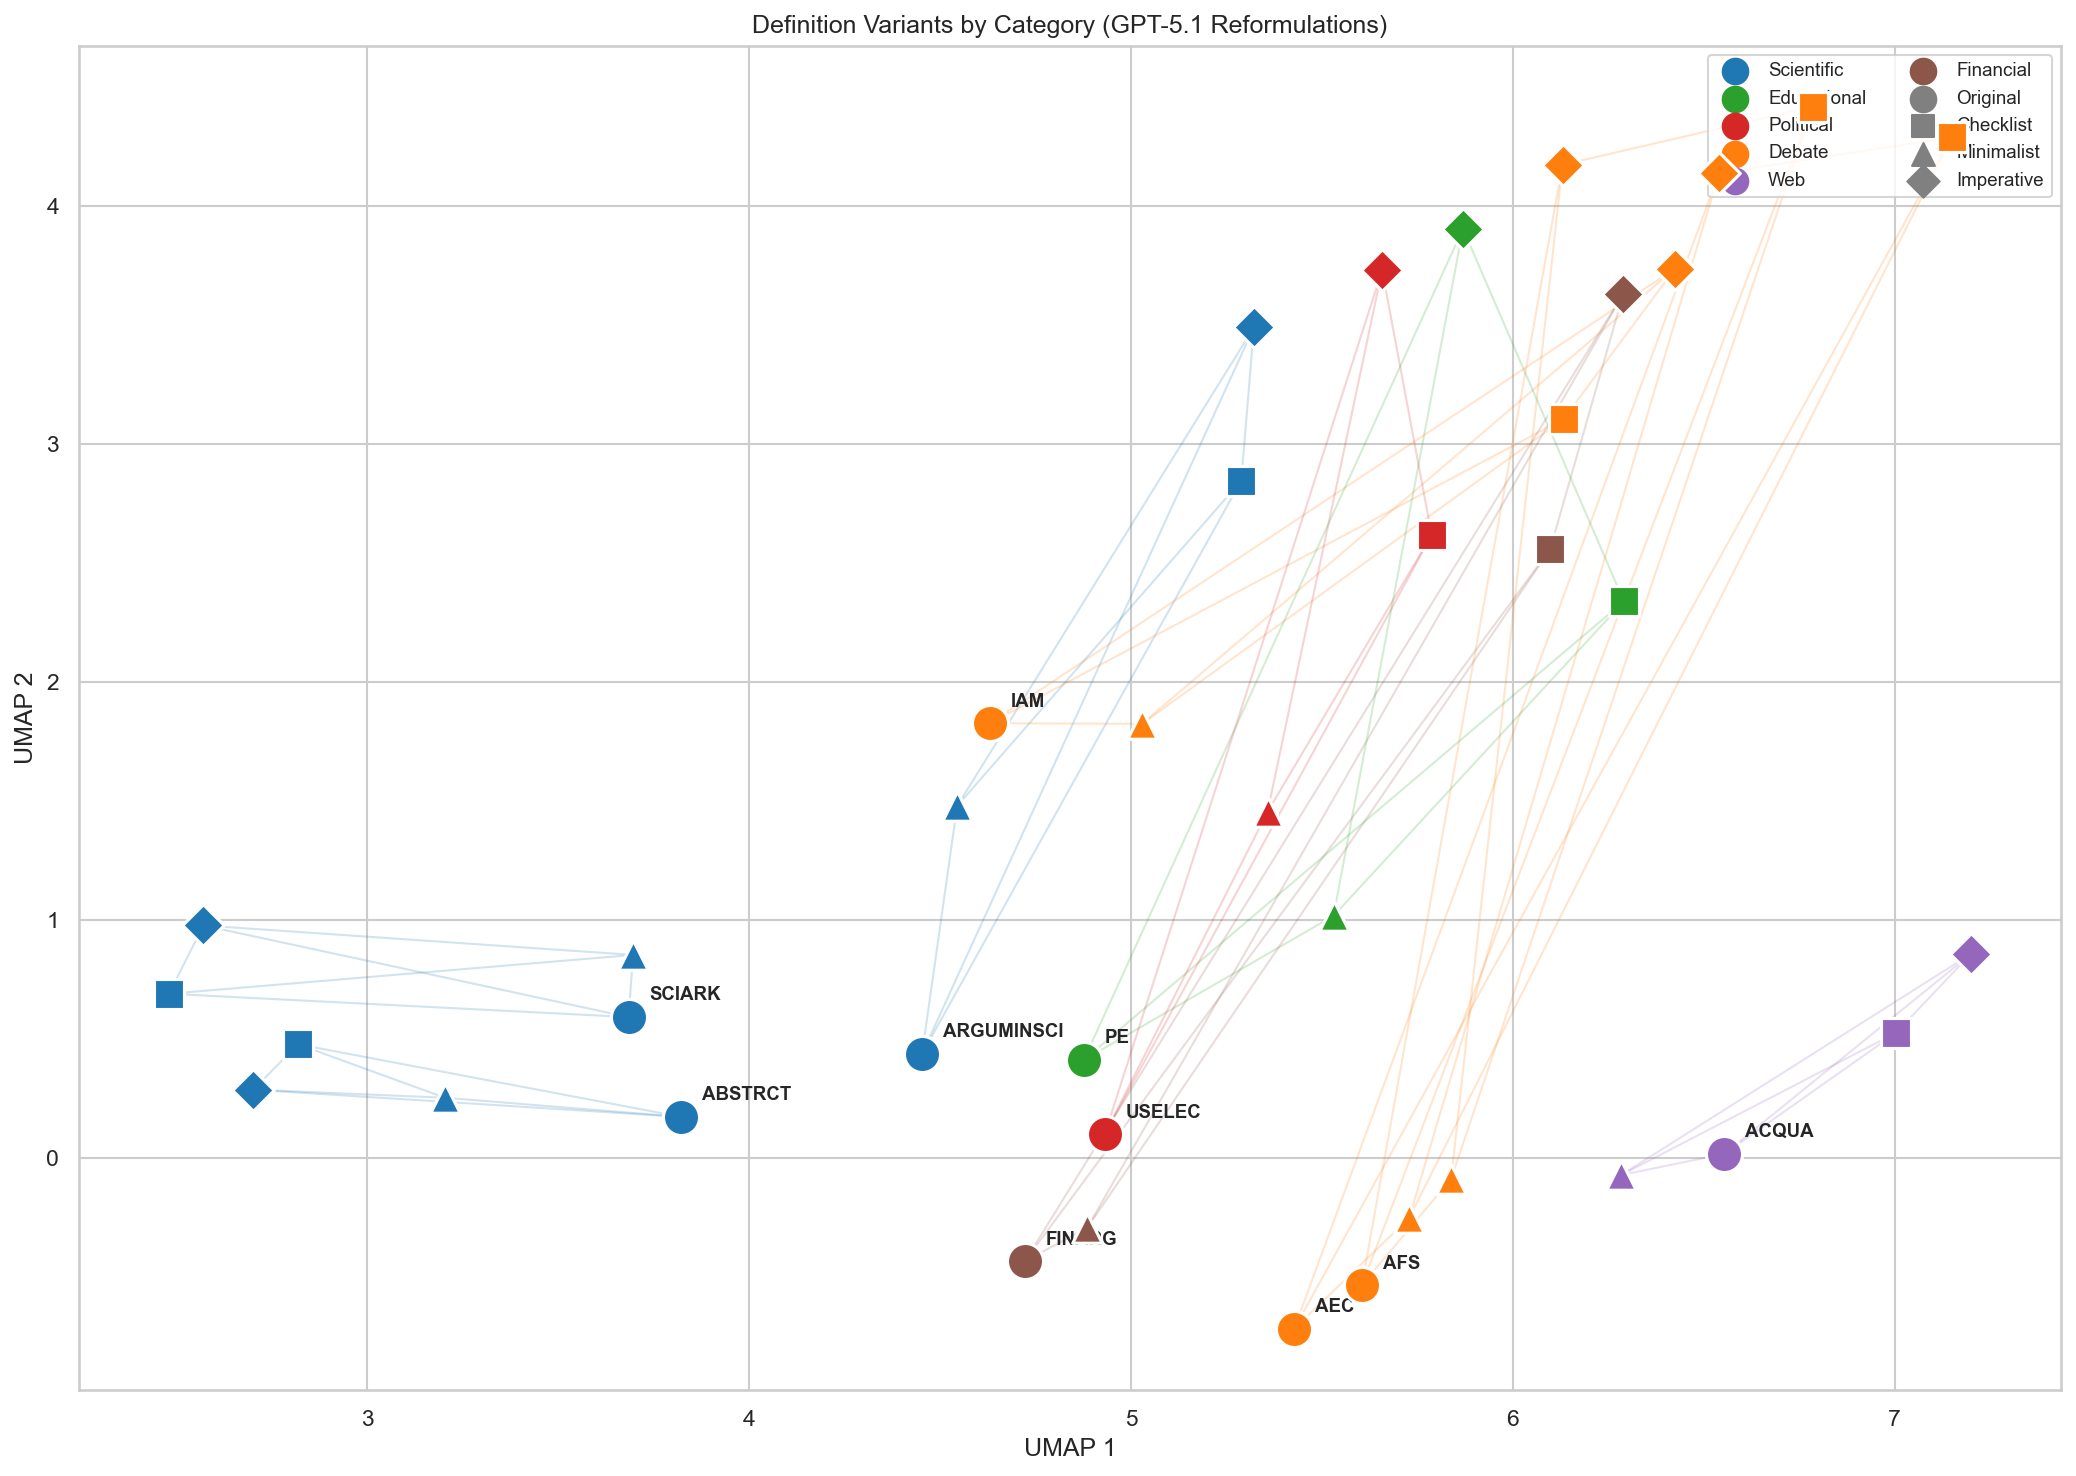

In [11]:
# Visualization: color by category, marker by style
STYLE_MARKERS = {"original": "o", "checklist": "s", "minimalist": "^", "imperative": "D"}

fig, ax = plt.subplots(figsize=(14, 10))

# Group by dataset to draw connecting lines
for ds in DATASETS:
    ds_indices = [i for i, (d, s) in enumerate(all_meta) if d == ds]
    ds_coords = coords_all[ds_indices]
    color = CATEGORY_COLORS[CATEGORIES[ds]]
    
    # Draw lines connecting all variants of same dataset
    for i in range(len(ds_coords)):
        for j in range(i+1, len(ds_coords)):
            ax.plot([ds_coords[i, 0], ds_coords[j, 0]], 
                    [ds_coords[i, 1], ds_coords[j, 1]], 
                    c=color, alpha=0.2, linewidth=1)

# Plot points
for i, (ds, style) in enumerate(all_meta):
    color = CATEGORY_COLORS[CATEGORIES[ds]]
    marker = STYLE_MARKERS[style]
    size = 300 if style == "original" else 200
    ax.scatter(coords_all[i, 0], coords_all[i, 1], c=color, s=size, marker=marker,
               edgecolors="white", linewidth=1.5, zorder=10)
    
    # Only annotate original
    if style == "original":
        ax.annotate(ds, (coords_all[i, 0], coords_all[i, 1]), fontsize=9, fontweight="bold",
                    xytext=(10, 8), textcoords="offset points")

# Category legend
for cat, color in CATEGORY_COLORS.items():
    ax.scatter([], [], c=color, s=150, marker="o", label=cat)

# Style legend
ax.scatter([], [], c="gray", s=150, marker="o", label="Original")
ax.scatter([], [], c="gray", s=120, marker="s", label="Checklist")
ax.scatter([], [], c="gray", s=120, marker="^", label="Minimalist")
ax.scatter([], [], c="gray", s=120, marker="D", label="Imperative")

ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("Definition Variants by Category (GPT-5.1 Reformulations)")
ax.legend(loc="upper right", fontsize=9, ncol=2)

plt.tight_layout()
plt.savefig("definition_variants_by_category.png", dpi=300, bbox_inches="tight")
plt.savefig("definition_variants_by_category.pdf", bbox_inches="tight")
plt.show()

In [ ]:
# Save generated definitions for GoLLIE training
import json

output = {
    "categories": CATEGORIES,
    "styles": list(CATEGORY_COLORS.keys()),
    "definitions": alt_definitions
}

with open("alt_definitions.json", "w") as f:
    json.dump(output, f, indent=2)

print(f"Saved {len(DATASETS)} datasets x {len(CATEGORY_COLORS)} styles = {len(DATASETS) * len(CATEGORY_COLORS)} definitions")

NameError: name 'STYLES' is not defined